In [3]:
import pandas as pd

df = pd.read_csv("city_day.csv")   # Change the filename if yours is different

print(df.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


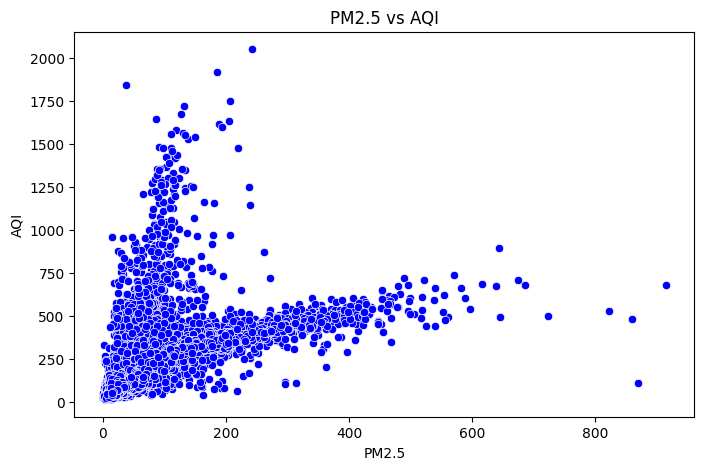

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="PM2.5",
    y="AQI",
    color="blue"
)

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.show()

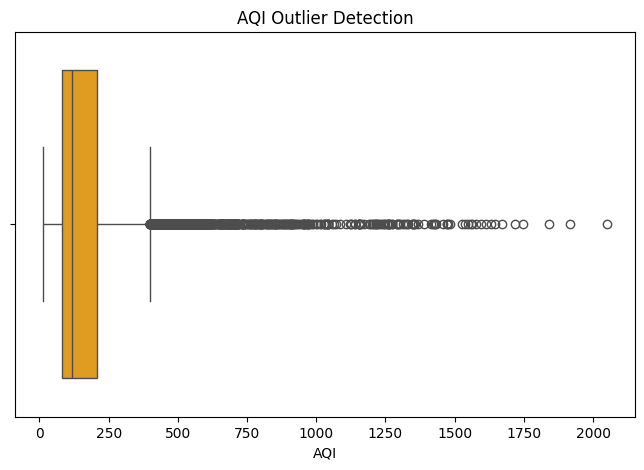

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["AQI"], color="orange")

plt.title("AQI Outlier Detection")

plt.show()

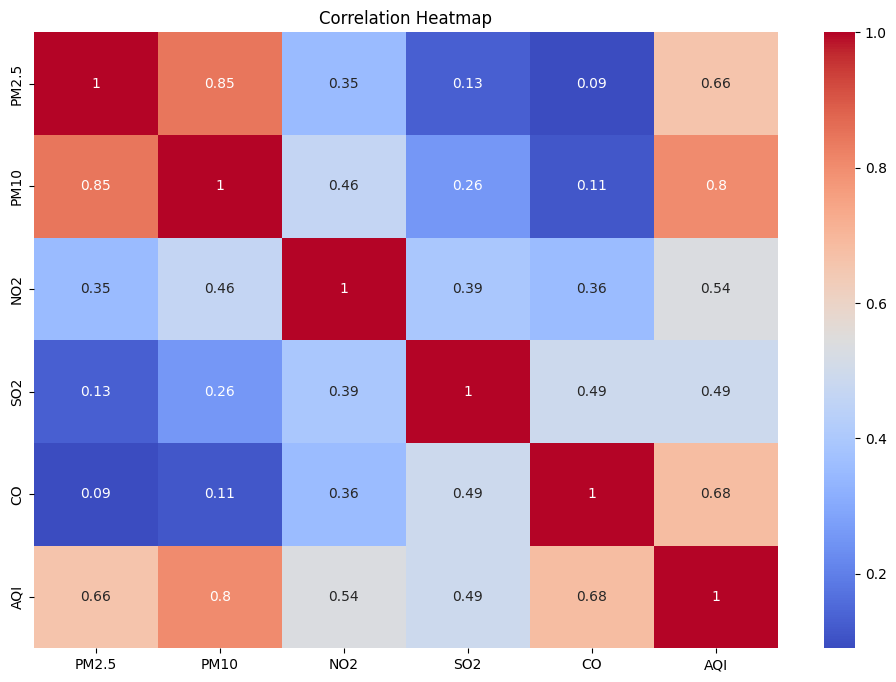

In [6]:
plt.figure(figsize=(12,8))

corr = df[["PM2.5","PM10","NO2","SO2","CO","AQI"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

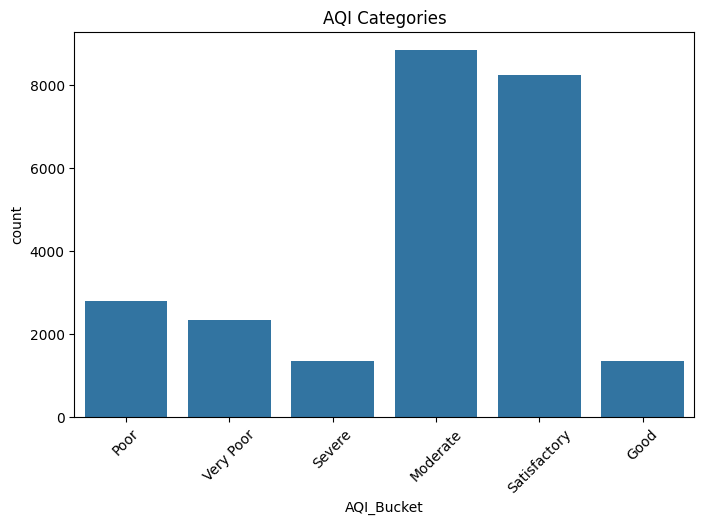

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AQI_Bucket"
)

plt.xticks(rotation=45)

plt.title("AQI Categories")

plt.show()

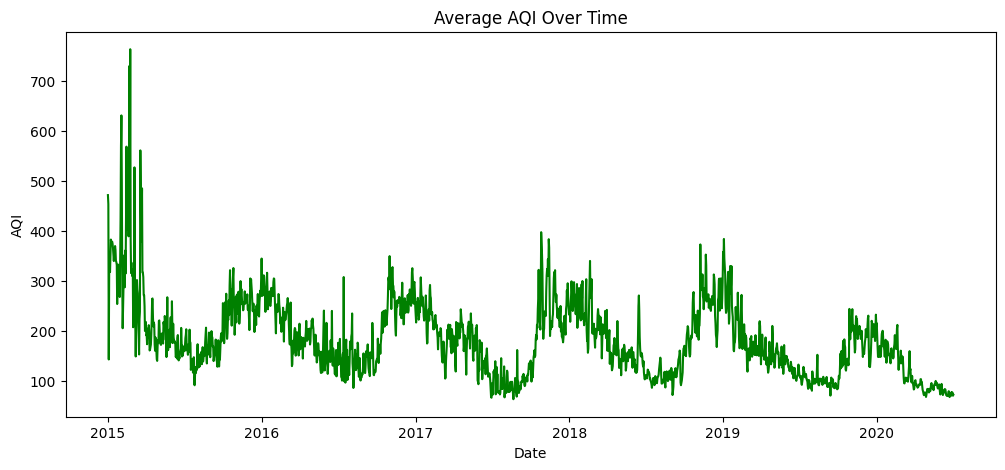

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

daily = df.groupby("Date")["AQI"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    daily,
    color="green"
)

plt.title("Average AQI Over Time")

plt.xlabel("Date")
plt.ylabel("AQI")

plt.show()


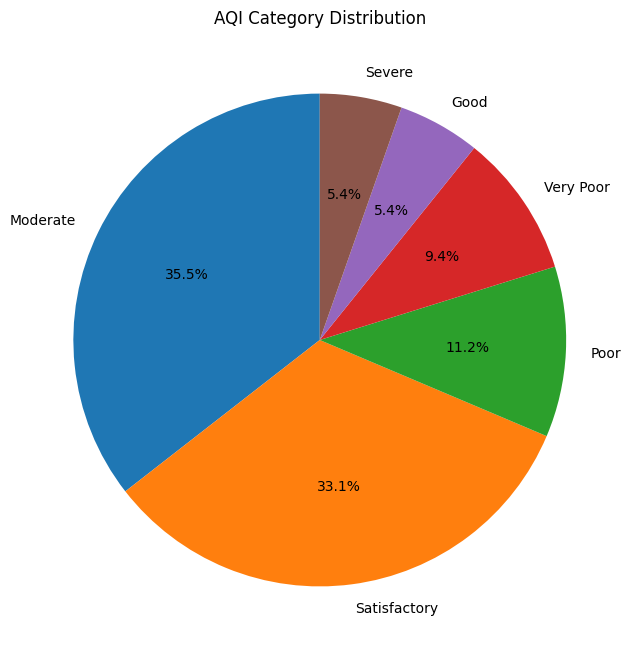

In [9]:
aqi = df["AQI_Bucket"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    aqi,
    labels=aqi.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("AQI Category Distribution")

plt.show()

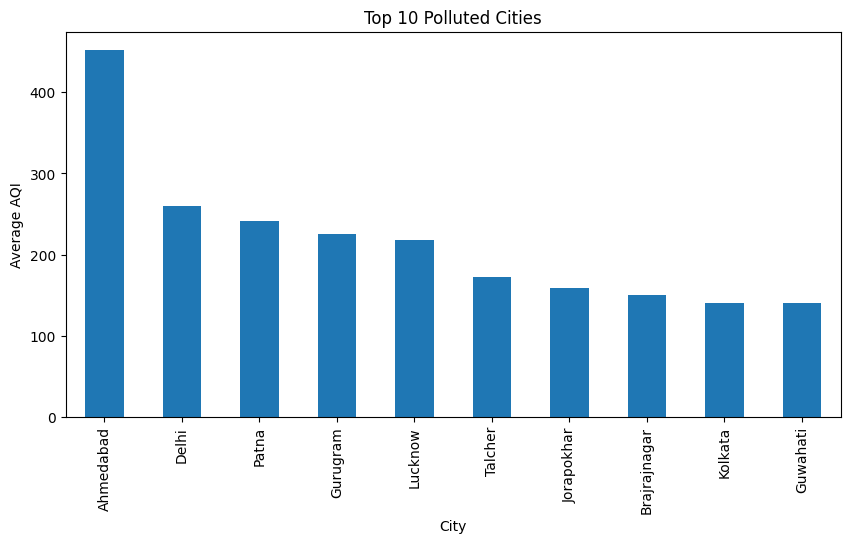

In [10]:
city = df.groupby("City")["AQI"].mean()

city = city.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

city.plot(kind="bar")

plt.title("Top 10 Polluted Cities")

plt.ylabel("Average AQI")

plt.show()

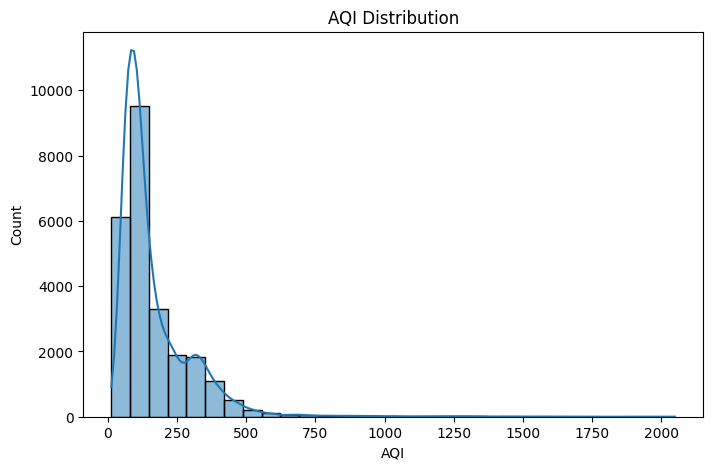

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["AQI"],
    bins=30,
    kde=True
)

plt.title("AQI Distribution")

plt.show()

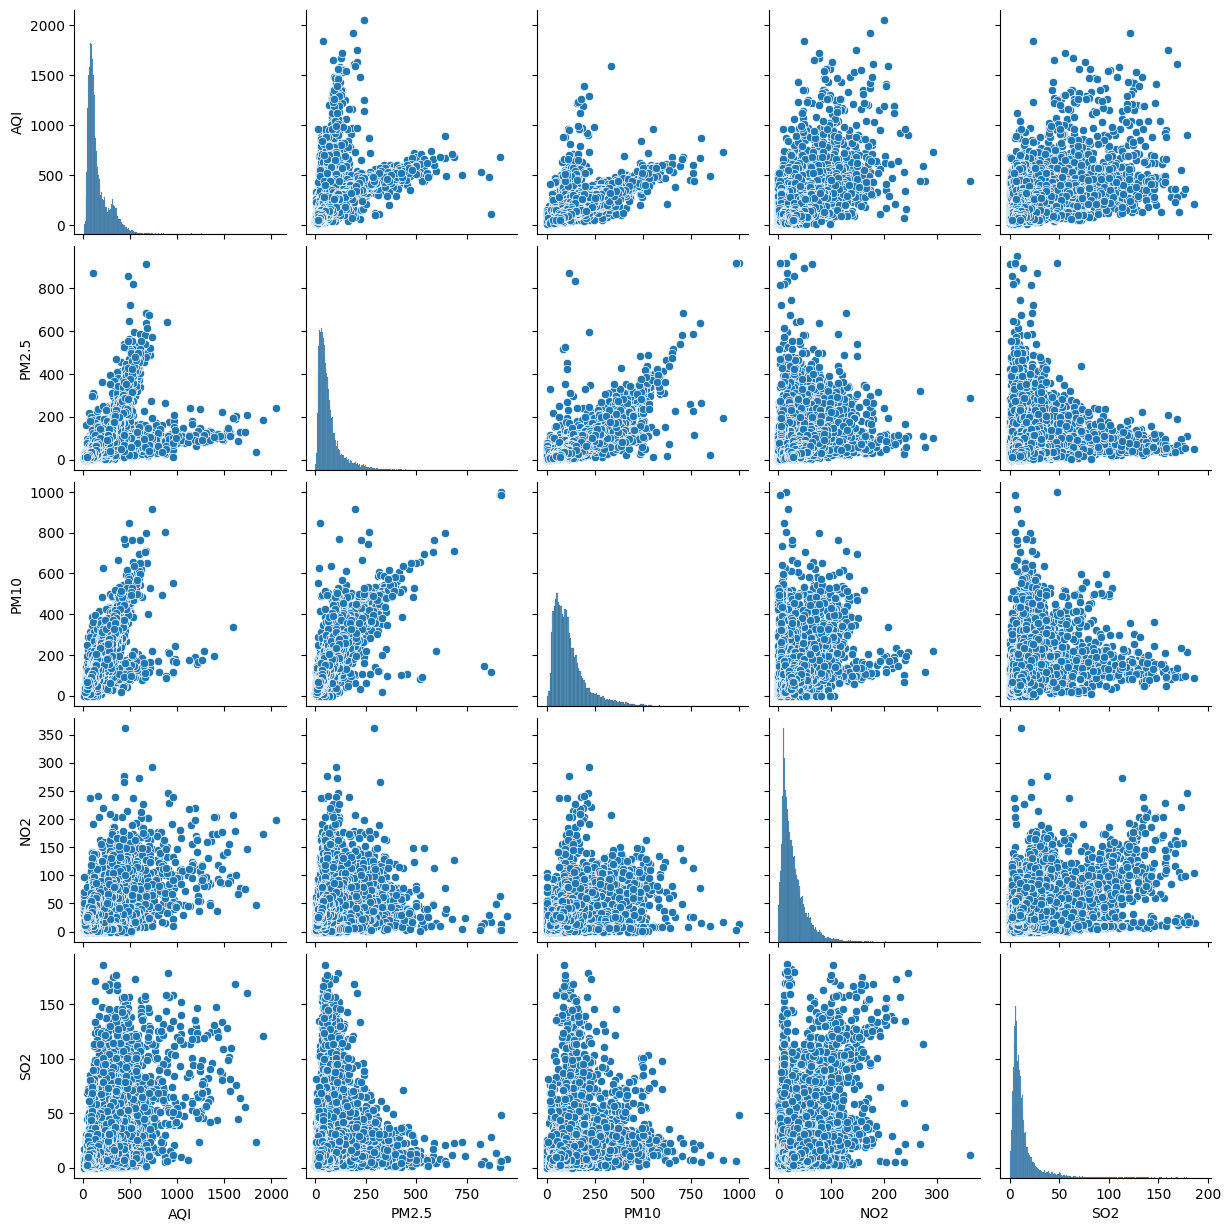

In [12]:
sns.pairplot(
    df[[
        "AQI",
        "PM2.5",
        "PM10",
        "NO2",
        "SO2"
    ]]
)

plt.show()

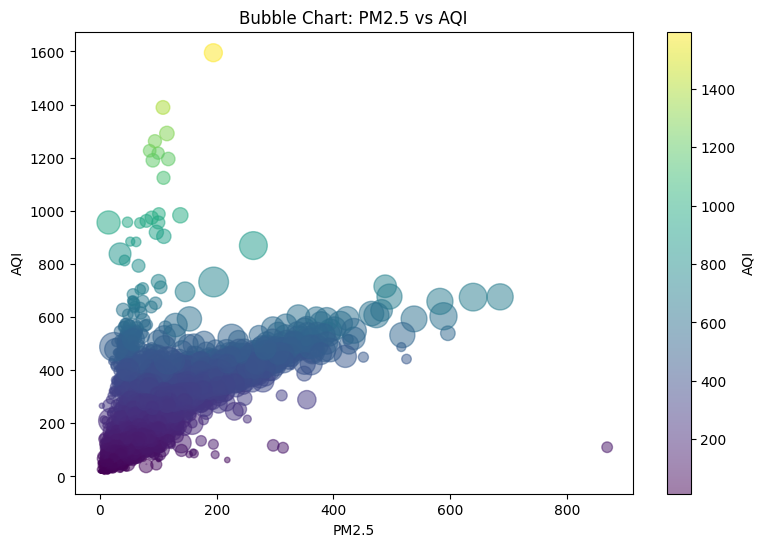

In [13]:
plt.figure(figsize=(9,6))

plt.scatter(
    df["PM2.5"],
    df["AQI"],
    s=df["PM10"]/2,
    alpha=0.5,
    c=df["AQI"],
    cmap="viridis"
)

plt.colorbar(label="AQI")

plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.title("Bubble Chart: PM2.5 vs AQI")

plt.show()

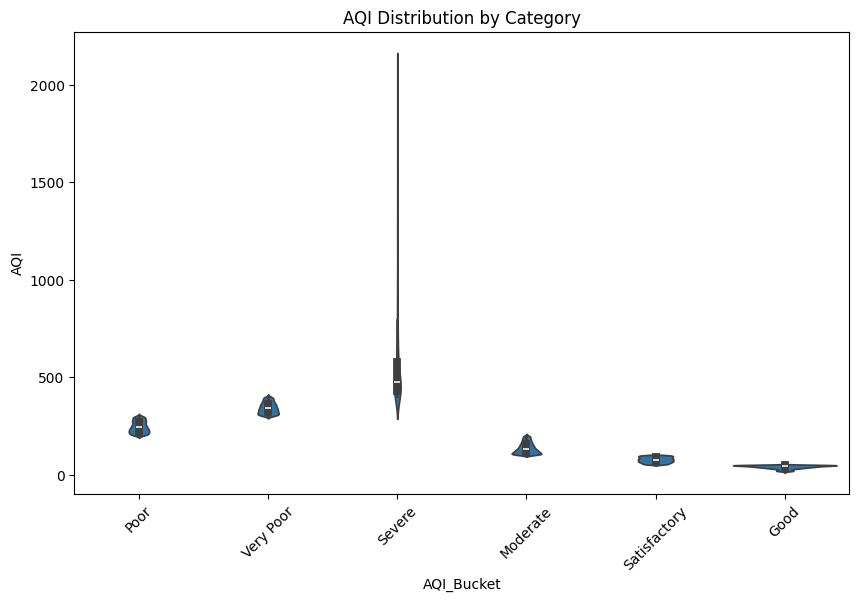

In [14]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="AQI_Bucket",
    y="AQI"
)

plt.xticks(rotation=45)

plt.title("AQI Distribution by Category")

plt.show()

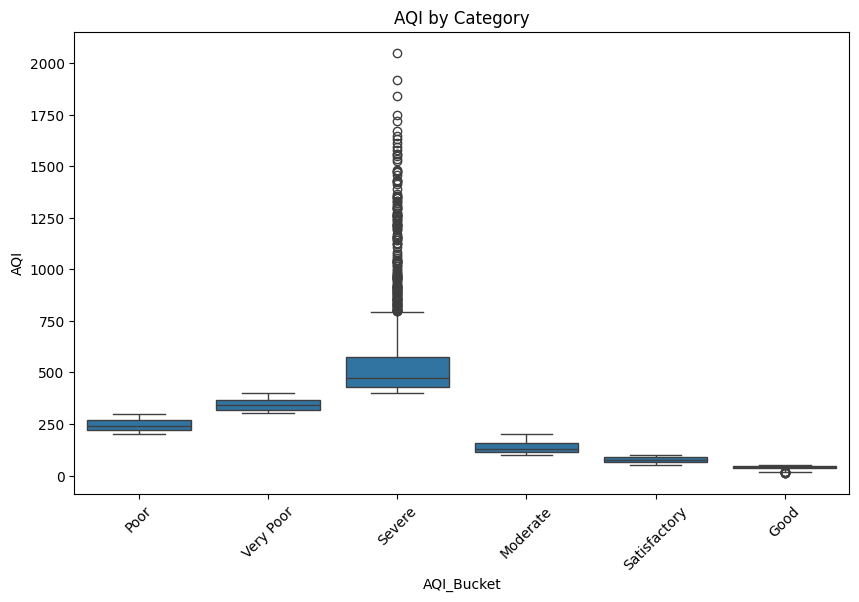

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="AQI_Bucket",
    y="AQI"
)

plt.xticks(rotation=45)

plt.title("AQI by Category")

plt.show()